In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
from kcircuit.shapes import Shape
from kcircuit.shapes import Rectangle
from kcircuit.shapes import Circle
from kcircuit.shapes import Taper
from kcircuit.structures import Circuit

<Axes: >

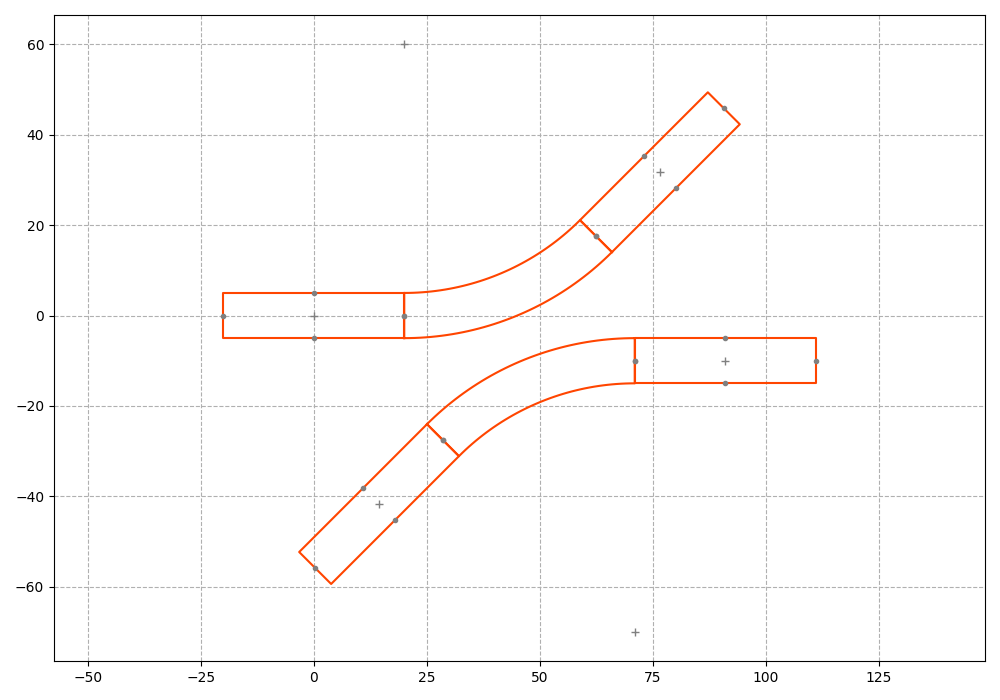

In [2]:
c1 = Circuit([
    Rectangle(10, 40).set_connectors(out_edge_idx=3),
    Circle(10, 60, 45).set_connectors(in_edge_idx=0, out_edge_idx=1),
    Rectangle(10, 40).set_connectors(in_edge_idx=3),
])
c1.build()

c2 = c1.copy()
c2.mirror(x_axis_pos=-5, y_axis_pos=45.5)

ax = c1.plot()
c2.plot(ax)

In [18]:
c1.to_klayout()

[(-20,-5;-20,5;20,5;20,-5),
 (20,-5;20,5;29,5;30,6;33,6;34,7;37,7;38,8;40,8;41,9;42,9;43,10;44,10;45,11;46,11;46,12;47,12;48,13;49,13;50,14;51,14;54,17;55,17;55,18;56,19;57,19;58,20;58,21;65,14;65,13;62,10;61,10;58,7;57,7;55,5;54,5;52,3;51,3;50,2;49,2;48,1;47,1;46,0;43,0;42,-1;39,-1;38,-2;36,-2;35,-3;31,-3;30,-4;21,-4),
 (65,14;58,21;87,49;94,42)]

Taper centre: x 55.0, y -0.0
Taper centre: x 0.0, y 0.0


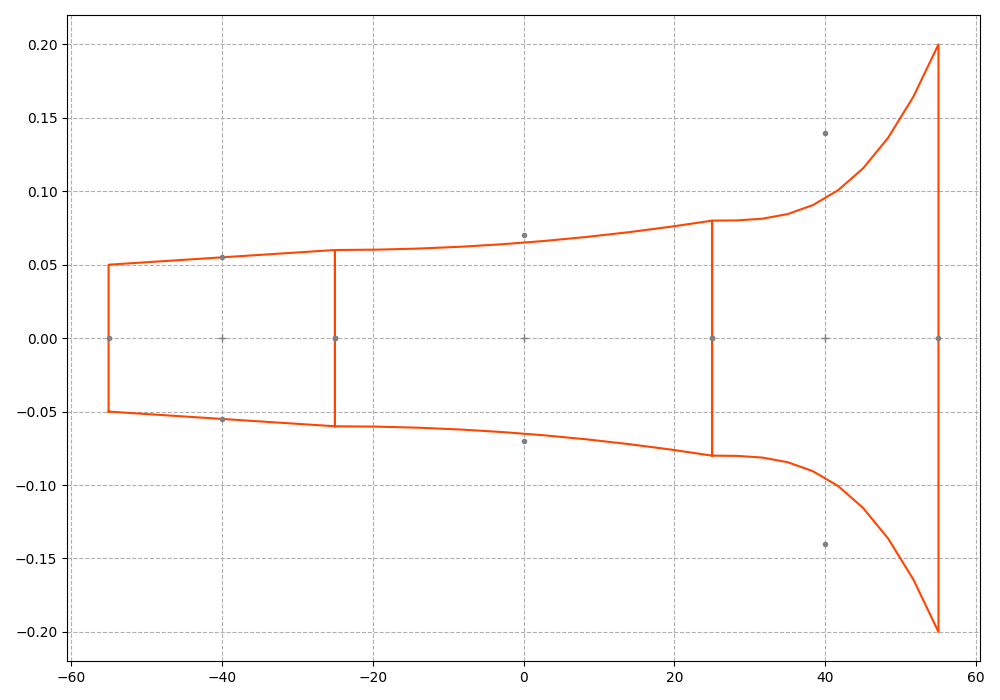

In [4]:
taper1 = Taper(0.12, 0.1, 30, 1)
taper2 = Taper(0.16, 0.12, 50, 2)
taper3 = Taper(0.4, 0.16, 30, 3)
taper1.rotate(180)
taper1.shift(taper1.limit_points()[1][0], 0)
taper2.rotate(180)
taper3.rotate(180)

circuit_config = [
    taper1.set_connectors(out_edge_idx=1),
    taper2.set_connectors(in_edge_idx=3, out_edge_idx=1),
    taper3.set_connectors(in_edge_idx=3, out_edge_idx=1),
]

taper = Circuit(circuit_config)
taper.build()
print(f"Taper centre: x {round(taper.centre().x, 3)}, y {round(taper.centre().y, 3)}")
taper.centralize()
print(f"Taper centre: x {round(taper.centre().x, 3)}, y {round(taper.centre().y, 3)}")
ax = taper.plot(allow_stretch=True)

In [5]:
def c_shape_circuit_config(taper_length: int) -> list[Shape]:
    total_len = 2000

    taper1 = Taper(0.4, 0.1, taper_length, 1)
    taper1.rotate(180)
    taper1.shift(taper1.limit_points()[1][0], 0)
    taper2 = Taper(0.4, 0.1, taper_length, 1)

    circuit_config: list[Shape] = [
        taper1.set_connectors(out_edge_idx=1),
        Rectangle(0.4, 100).set_connectors(in_edge_idx=1, out_edge_idx=3),
        Circle(0.4, 22, 90).set_connectors(in_edge_idx=0, out_edge_idx=1),
        Rectangle(0.4, 40).set_connectors(in_edge_idx=1, out_edge_idx=3),
        Circle(0.4, 22, 90).set_connectors(in_edge_idx=1, out_edge_idx=0),
        Rectangle(0.4, total_len - taper_length).set_connectors(in_edge_idx=1, out_edge_idx=3),
        Circle(0.4, 22, 90).set_connectors(in_edge_idx=1, out_edge_idx=0),
        Rectangle(0.4, 80).set_connectors(in_edge_idx=3, out_edge_idx=1),
        Circle(0.4, 22, 90).set_connectors(in_edge_idx=1, out_edge_idx=0),
        Rectangle(0.4, total_len - taper_length).set_connectors(in_edge_idx=3, out_edge_idx=1),
        Circle(0.4, 22, 90).set_connectors(in_edge_idx=0, out_edge_idx=1),
        Rectangle(0.4, 40).set_connectors(in_edge_idx=3, out_edge_idx=1),
        Circle(0.4, 22, 90).set_connectors(in_edge_idx=1, out_edge_idx=0),
        Rectangle(0.4, 100).set_connectors(in_edge_idx=3, out_edge_idx=1),
        taper2.set_connectors(in_edge_idx=1, out_edge_idx=3),
    ]
    return circuit_config

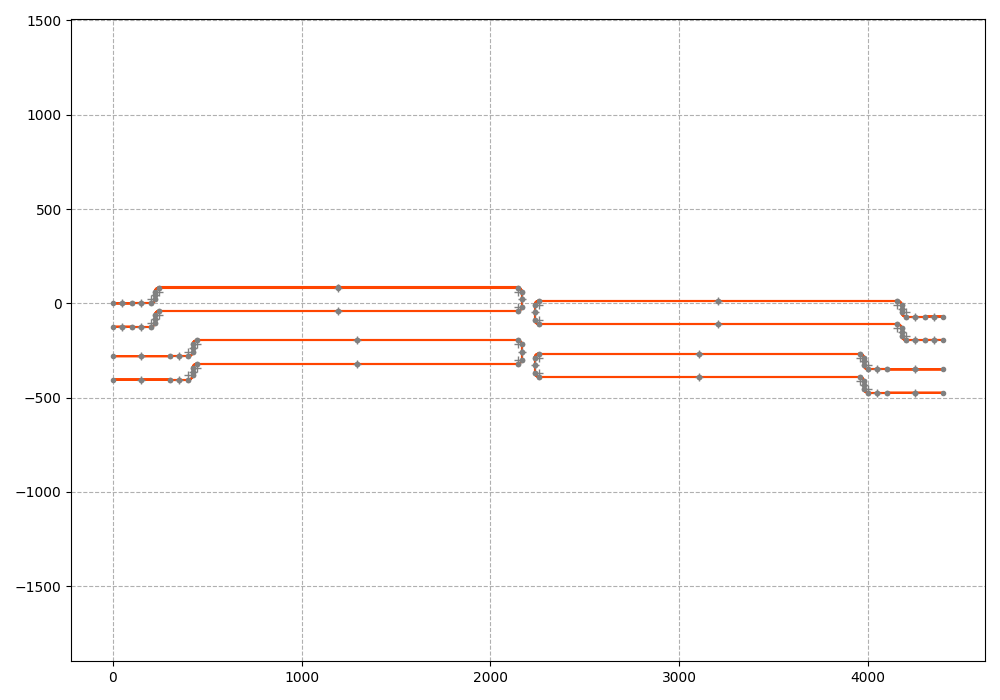

In [6]:
plt.close("all")
# fig, ax1 = plt.subplots(figsize=(13, 4))

c1 = Circuit(c_shape_circuit_config(100))
c1.build()

c2 = Circuit(c_shape_circuit_config(300))
c2.build()
c2.shift(0, -280)

c4 = c1.copy()
c4.shift(0, -70)
c4.mirror(y_axis_pos=2200)

c5 = c2.copy()
c5.shift(0, -70)
c5.mirror(y_axis_pos=2200)

ax1 = c1.plot()
ax1 = c2.plot(ax1)
ax1 = c4.plot(ax1)
ax1 = c5.plot(ax1)